# Build a minimal language model from scratch

This notebook is meant to be read **step by step**. Each numbered section adds **one main idea**. On your first pass, run cells **from top to bottom** so names like `device`, `EN_CORPUS`, and the model classes stay in order.

---

### The story in plain language

0. **Warm-up (Q/K/V intuition)** — We build attention from **embedding vectors** and **dot products**, then add learned **Q**, **K**, and **V** views of the same hidden state.

1. **Attention** — For each word in a sentence, we compute a **weighted mix** of information from other words. Those weights come from how well each pair of words “matches” (via *keys* and *queries*).

2. **The position problem** — Attention alone does not know if a word is first or last. We show that with a tiny example.

3. **Positional encoding** — We add a signal that depends on **where** the word sits in the sentence. First we use a simple **learned** vector per index; then the classic **sine/cosine** pattern.

4. **Transformer blocks** — We stack: attention → small neural net (feed-forward) → skip connections and normalization.

5. **Encoder–decoder** — One stack reads English; another stack writes Spanish while **looking at** the English stack (*cross-attention*). We use a **small** dataset where many sentences **share words**, so the model can sometimes translate a **new** English sentence it never memorized verbatim.

6. **Encoder-only** — Every word can see **both directions** (good for “fill in the blank”). We mask padding so empty slots do not pollute attention.

7. **Decoder-only** — Like **GPT**: each word may only look **backward** in the sentence. We train “predict the next word” and then try **generation** from a short prompt.

---

### Why everything is “tiny”

Big models need big computers. Here we use **small widths**, **few layers**, and **short training** so you can finish in about **1–3 minutes on a laptop CPU** (often faster on a GPU). The goal is **understanding**, not state-of-the-art quality.

### One shared English list

**`EN_CORPUS`** is a single list of English lines. The **same** list is reused later for encoder-only and decoder-only tasks. The translation section adds **`ES_TRANSLATIONS`**: one Spanish line aligned with each English line.

### Software

Install with: `pip install -r requirements.txt` (needs `torch`, `matplotlib`, `numpy`). The last section can draw a small **architecture diagram** if you install **pygraphviz** and the system **Graphviz** tools.

### If something looks wrong

- If a **loss plot is empty** or loss is `NaN`, re-run from the **first code cell** after changing code; padding masks must stay consistent.
- If **generation** only repeats your prompt, see section 8: the context must not start with an early `<eos>` token.

### After the next code cell

That cell imports libraries, picks `cpu` or `cuda`, and defines small plotting helpers. Run it once before the rest.


In [29]:
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
import math
import random
from dataclasses import dataclass
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def plot_loss_curve(losses, title="Training loss"):
    if not losses:
        print(f"{title}: no steps recorded — nothing to plot.")
        return
    arr = np.asarray(losses, dtype=np.float64)
    if np.isnan(arr).any():
        print(f"{title}: loss contains NaN (often bad padding mask on attention).")
    plt.figure(figsize=(7, 3.5))
    plt.plot(losses, lw=2, color="steelblue")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    print(f"{title}: n={len(losses)}  loss_first={arr[0]:.4f}  loss_last={arr[-1]:.4f}")
    plt.show()

def plot_attention(attn: torch.Tensor, row_labels=None, col_labels=None, title="Attention weights"):
    # attn: (n_query, n_key) numpy or tensor
    a = attn.detach().float().cpu().numpy()
    plt.figure(figsize=(5, 4))
    plt.imshow(a, cmap="magma", vmin=0, vmax=a.max() if a.size else 1)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(title)
    if row_labels is not None:
        plt.yticks(range(len(row_labels)), row_labels)
    if col_labels is not None:
        plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha="right")
    plt.xlabel("key position")
    plt.ylabel("query position")
    plt.tight_layout()
    plt.show()


device: cpu


## 0. Warm-up: embeddings, dot products, then Q, K, V

Before we open the full attention code, it helps to see the **same math** on a **tiny** example.

### Step 1 — each word is a vector

Pick a short sentence like **“i love cats”**. After an embedding layer, each word is a point in space: a list of numbers (a **vector**). Similar ideas should land in **similar directions** *after training*; here we just use small random vectors so you can watch the mechanics.

### Step 2 — a dot product is a simple “match score”

The **dot product** between two vectors is one number. If it is **large and positive**, the two arrows point in a **similar** direction (they “agree”). If it is near zero or negative, they are **less aligned**. So a dot product is a crude **similarity score** between two words *in the current embedding space*.

### Shapes and symbols (read once; we reuse them below)

- **$T$** — number of tokens in the little sentence (here $T=3$).
- **`d`** — length of each **token embedding vector** in the warm-up code (`nn.Embedding(..., d)`). Every dot product “score” below is between **two `d`-dimensional** vectors, so a natural scale factor is $\sqrt{d}$ (same variance-heuristic idea as in §1).
- **$B$** — batch size (number of sentences processed together). The toy code often uses $B=1$; the library shapes later are written `(B, T, …)`.

**Preview of §1 vocabulary (not used in the code cell below yet, but standard everywhere else):**

- **`d_model`** — hidden width of the transformer: each position carries one vector in $\mathbb{R}^{d_{\text{model}}}$ along the residual stream.
- **`n_heads`** — how many **parallel** attention heads we stack.
- **`d_head`** — per-head width, always **`d_head = d_model // n_heads`**. Inside each head, queries and keys live in $\mathbb{R}^{d_{\text{head}}}$, and the attention implementation scales scores by $1/\sqrt{d_{\text{head}}}$.

In this warm-up we intentionally set **`d_head = d` and `n_heads = 1` conceptually** so you can focus on the algebra before the extra reshape.

### Step 3 — one row of attention (without Q/K yet)

Fix a **query position** (for example the middle word, “love”). You are answering: *“for this position, how useful is every other position?”*

1. Take the embedding vector at the query position, $E_{\text{love}}$.
2. Dot it with **each** column vector $E_{\text{i}}$, $E_{\text{love}}$, $E_{\text{cats}}$. That gives **one row** of numbers — one score per key position.
3. Apply **softmax** along that row so the scores become **weights that add to 1**. Those weights mean: “how much should ‘love’ blend from ‘i’, from itself, from ‘cats’?”
4. **Mix** the embeddings with those weights (same vectors you used for scoring). Each output row is a **weighted sum** of the sentence — a soft, differentiable “lookup.”

So **one row** = “one position’s view of how much to borrow from every other slot.” The code cell below prints a full **score matrix**; each **row** is exactly that process for one query word.

### Step 3b — Why softmax? Why should the weights add to 1?

**Short answer:** we want each output position to be a **blend** of value vectors where the blend coefficients are **non‑negative** and **add to 1**. That is a **convex combination**: you are taking a “weighted average” of the things you attend to, not scaling the whole sentence by an arbitrary factor.

**Why not use raw dot products as weights?** Dot scores can be negative, huge, or tiny depending on vector lengths and training stage. If you mixed $V$ with those raw scores, the **scale** of the output could explode or collapse, and negatives would **subtract** information in a way that is harder to stabilize during training.

**What softmax does on one row:** it turns any row of scores $(s_1,\dots,s_T)$ into **positive** weights $(w_1,\dots,w_T)$ with $w_1+\cdots+w_T=1$. Think of it as converting “loudness of each match” into a **probability‑like budget**: “among these keys, what fraction of my focus goes to each?” Raising one weight **automatically** lowers the others (they compete for a fixed total of 1).

**Differentiability:** softmax is smooth, so backpropagation can adjust $Q$ and $K$ to slightly increase useful keys and decrease useless ones. A hard **argmax** (“only listen to the single best key”) would be much harder to train with gradient descent.

**Not the only possible rule:** some designs use other normalizations or **sparse** attention. The transformer default is softmax because it is simple, stable, and works extremely well in practice.

**Do we avoid vanishing gradients “because of softmax”?** Not quite — softmax can cause its **own** saturation problem. If one logit is *much* larger than the others, the row becomes nearly **one‑hot** (almost all mass on one key). Then small changes to the *losing* logits barely change the weights, so gradients **through the softmax** to those keys can be **tiny** (the classic “saturated softmax” picture).

That is **different** from the old **RNN** problem (signals fading across hundreds of recurrent steps). Here the depth is mostly in **layers**, and each attention block has **skip connections** that give gradients alternate paths.

Transformers still use tricks to keep softmax from getting *too* sharp too early: most famously **scaling** the logits inversely with the **square root of the inner dimension of the dot product**. In this §0 toy example that inner dimension is **`d`**, so the code divides by $\sqrt{d}$. Starting in **§1** the same divisor is written as $\sqrt{d_{\text{head}}}$ because each head’s $Q$ and $K$ vectors have length **`d_head = d_model // n_heads`** (defined in the notation box there). **Layer normalization**, **residuals**, and **multi‑head** attention also help training stay healthy. So: softmax is not magic against vanishing gradients — it is a useful, smooth choice whose sharpness is **managed** by the rest of the architecture.

### Step 4 — same embeddings for scoring: what works, what breaks

#### 4a — the good news

Using **one** embedding table for both sides of the dot product is simple and already gives you **variable-length mixing**: every position can attend to every position with learned vectors.

#### 4b — the structural snag: scores are symmetric

If the score between position $i$ and $j$ is $\text{dot}(E_i, E_j)$, then

$$
\text{score}(i \rightarrow j) = \text{dot}(E_i, E_j) = \text{dot}(E_j, E_i) = \text{score}(j \rightarrow i).
$$

So the **raw** attention score from “love” to “cats” **must equal** the score from “cats” to “love.” The whole **score matrix** (before softmax) is **symmetric** along its diagonal.

That is not “wrong math,” but it is a **strong prior**: the model is not free to say *“love looks hard at cats, but cats barely look back at love.”* Whatever match strength you assign in one direction, you **automatically** assign in the reverse direction for the purpose of **scoring**.

After **softmax per row**, the **attention weight** matrices are usually **not** symmetric (each row is normalized separately). So you still get **different blend weights** for “love” than for “cats.” The limitation is subtler: you tied the **underlying similarity meter** so that “how much love matches cats” equals “how much cats matches love” **before** each row’s softmax reshapes things.

#### 4c — two roles, one vector: what we actually want

Intuitively we want **two different jobs** at each position:

- **Query role** — “What evidence am I **looking for** right now?” (syntax: object of a verb; semantics: who did the action.)
- **Key role** — “What **cues** do I expose so others can find me?” (e.g. “I am an object-shaped word,” “I am a subject.”)

Those are **different functions of the same word**. With a **single** embedding $E$, both roles are forced to use the **identical** list of numbers, and the score **must** treat $(i,j)$ and $(j,i)$ the same before softmax.

#### 4d — why **Q** and **K** (two linear views) fix it

Instead of dotting $E_i$ with $E_j$, we first map the hidden state through **two learned linear maps**:

$$
Q_i = W_Q\, E_i, \qquad K_j = W_K\, E_j.
$$

The score becomes $\text{dot}(Q_i, K_j)$. There is **no** reason this has to equal $\text{dot}(Q_j, K_i)$: we broke the symmetry by letting **“how I ask”** ($W_Q$) differ from **“how I present myself to be matched”** ($W_K$).

Think of it as **two projections** of the same token into two subspaces: one optimized for **asking**, one for **being found**. The network can learn, for example, that **verbs** query in a subspace where **objects** have strong keys — without forcing objects to query verbs in the exact same way.

#### 4e — why **V** is separate from **K**

Even after you decide **how much** to attend (weights from $QK^\top$), you might want the **content you blend** to live in a **third** subspace:

$$
V_j = W_V\, E_j.
$$

**Keys** answer “should I pay attention here?” **Values** answer “**what information** do I pass along if I do?” Splitting them lets the model keep **matching** (high-level compatibility) and **message passing** (what gets added into the residual stream) from stepping on each other.

The next code cell shows the symmetric $\text{dot}(E,E)$ table next to a $\text{dot}(Q,K)$ table from random $W_Q, W_K$ so you can **see** symmetry vs asymmetry.

The next section (**§1**) packages this into `MultiHeadAttention`: several heads in parallel, masks, dropout, and the full residual stack you will train.


Token order: ['i', 'love', 'cats']

(A) Dot(E_i, E_j) — score table (should be symmetric):
[[ 1.444  0.979 -0.122]
 [ 0.979  1.873 -0.166]
 [-0.122 -0.166  0.666]]
(A) max |score[i,j] - score[j,i]|: 0.0

(A) Row-softmax -> weights (row i = query at position i). Example row 1 (query = 'love'):
[0.329 0.451 0.22 ]

(A) After mixing, each row is still a vector of length d: (3, 8)


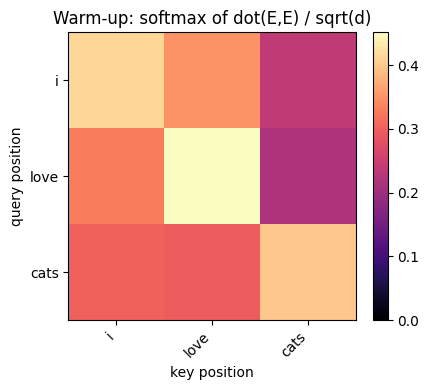


(B) Dot(Q_i, K_j) / sqrt(d) — QK table need not be symmetric:
[[-0.007  0.017 -0.005]
 [-0.107 -0.208 -0.035]
 [-0.06  -0.039 -0.021]]
(B) max |score[i,j] - score[j,i]|: 0.12335536628961563

(B) Output shape after mixing V: (1, 3, 8)


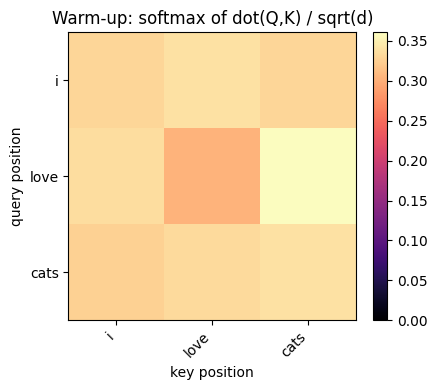


Takeaway: dot products turn vectors into match scores; softmax turns scores into weights;
Q/K split lets 'what I ask' differ from 'what I show'; V is what actually gets blended.


In [45]:
# --- Warm-up: embeddings -> dots -> softmax mix -> separate Q, K, V ---
# Run the imports cell above first (it defines `device`, `plot_attention`, etc.).

set_seed(123)
words = ["i", "love", "cats"]
d = 8
emb = nn.Embedding(len(words), d)

# Pedagogical demo only: turn off autograd so tensors are plain numbers for .numpy() / plots.
with torch.no_grad():
    emb.weight.normal_(0, 0.4)
    idx = torch.arange(len(words), device=device).unsqueeze(0)  # (1, T)
    E = emb(idx)  # (1, T, d)
    H = E[0]  # (T, d) — drop batch for printing

    # --- A) Pairwise dot products using the SAME vectors for "question" and "answer"
    raw_scores = H @ H.T  # (T, T); symmetric: dot(E_i, E_j) == dot(E_j, E_i)
    print("Token order:", words)
    print("\n(A) Dot(E_i, E_j) — score table (should be symmetric):")
    print(raw_scores.cpu().numpy().round(3))
    print("(A) max |score[i,j] - score[j,i]|:", (raw_scores - raw_scores.T).abs().max().item())

    scale = math.sqrt(d)
    attn_same = F.softmax(raw_scores / scale, dim=-1)
    print("\n(A) Row-softmax -> weights (row i = query at position i). Example row 1 (query = 'love'):")
    print(attn_same[1].cpu().numpy().round(3))

    print("\n(A) After mixing, each row is still a vector of length d:", tuple((attn_same @ H).shape))

    plot_attention(attn_same, row_labels=words, col_labels=words, title="Warm-up: softmax of dot(E,E) / sqrt(d)")

    # --- B) Q, K, V as three learned linear projections (one conceptual head).
    # Here d_head == d on purpose: same as §1 with n_heads=1 and d_model=d.
    d_head = d
    Wq = nn.Linear(d, d_head, bias=False)
    Wk = nn.Linear(d, d_head, bias=False)
    Wv = nn.Linear(d, d_head, bias=False)
    nn.init.normal_(Wq.weight, 0, 0.25)
    nn.init.normal_(Wk.weight, 0, 0.25)
    nn.init.normal_(Wv.weight, 0, 0.25)

    Q = Wq(E)  # (1, T, d_head)
    K = Wk(E)
    Vv = Wv(E)
    qk_scores = (Q @ K.transpose(-2, -1)) / math.sqrt(d_head)
    attn_qk = F.softmax(qk_scores, dim=-1)
    out = attn_qk @ Vv

    print("\n(B) Dot(Q_i, K_j) / sqrt(d) — QK table need not be symmetric:")
    print(qk_scores[0].cpu().numpy().round(3))
    S = qk_scores[0]
    print("(B) max |score[i,j] - score[j,i]|:", (S - S.T).abs().max().item())
    print("\n(B) Output shape after mixing V:", tuple(out.shape))

    plot_attention(attn_qk[0], row_labels=words, col_labels=words, title="Warm-up: softmax of dot(Q,K) / sqrt(d)")

print(
    "\nTakeaway: dot products turn vectors into match scores; softmax turns scores into weights;"
    "\nQ/K split lets 'what I ask' differ from 'what I show'; V is what actually gets blended."
)


## 1. Scaled dot-product attention

**Section 0** walked through the same pieces on a toy sentence: dot scores, softmax weights, then separate **Q**, **K**, and **V** projections. Here we put that recipe into clean functions and add **multi-head** attention.

We start with the core operation used inside transformers.

### Notation (define once; the code cell below matches these names)

- **`d_model`** — hidden size: each token position carries a vector $x \in \mathbb{R}^{d_{\text{model}}}$ after embedding / residual updates.
- **`n_heads`** — number of **parallel** attention heads (an integer $\geq 1$).
- **`d_head`** — **per-head** width, defined only when `d_model` is divisible by `n_heads`:

$$
d_{\text{head}} \;:=\; \frac{d_{\text{model}}}{n_{\text{heads}}}
$$

(Integer division in Python: `d_model // n_heads`.)


Inside each head, the linear maps produce queries and keys in $\mathbb{R}^{d_{\text{head}}}$ so that each score is a dot product of two vectors of length **d_head**.

- **`d_k` (paper)** — in Vaswani et al. the denominator is written $\sqrt{d_k}$; in our implementation $d_k$ is exactly this same inner dimension, i.e. **`d_k = d_head`** for the tensors passed into `scaled_dot_product_attention`.

Batch / sequence shapes we will see: **`B`** batches, **`T`** (or `Tq`, `Tk`) token positions; attention weights have shape `(B, n_heads, Tq, Tk)` after softmax along the key axis.

### Step 1 — three matrices

For each token position we will have three vectors:

- **Query** *Q* — “what am I looking for?”
- **Key** *K* — “what do I advertise?”
- **Value** *V* — “if you pick me, what information do you actually pass along?”

In code, *Q*, *K*, and *V* are built from the same hidden vectors by three learned linear layers (not shown in the formula below, but that is what `MultiHeadAttention` does).

### Step 2 — match queries to keys

We compare every query to every key with a dot product. That gives a **score table**: one number per (query position, key position) pair.

Those dot products are between vectors of length **d_head** (see notation above). We divide by $\sqrt{d_{\text{head}}}$ so that, under the usual “coordinates are roughly unit-variance” heuristic, the logits do not grow systematically with embedding width. Without scaling, dot products would tend to be larger when **d_head** is larger, softmax would become extremely sharp, and training is harder. The same scaling constant appears in the formula as $\sqrt{d_k}$.

### Step 3 — turn scores into weights

We apply **softmax** along the key axis. Each row becomes **non-negative numbers that add up to 1**. Those are the **attention weights**.

### Step 4 — mix the values

We multiply those weights into *V* and sum. Intuition: each position becomes a **blend** of value vectors from all positions, weighted by how relevant each key was.

### The formula (same idea as the steps)

$$
\mathrm{Attention}(Q,K,V) = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

Here $d_k$ is the **inner dimension** of the matrix multiply $QK^\top$ along the query/key feature axis — in our code the tensors are shaped so **`d_k` equals `d_head`** from the notation box above.

### Masks (we use them later)

Sometimes we must **forbid** looking at certain positions (for example padding, or future words). We set forbidden scores to **minus infinity** before softmax so their weight becomes **zero**.

- **Padding mask** — “ignore empty slots at the end of a batch.”
- **Causal mask** — “when generating left-to-right, do not peek at future tokens.”

The next code cell defines attention and multi-head attention, then plots a random heatmap so you see the **shape** of an attention matrix before training teaches it structure.


torch.Size([2, 5, 64]) torch.Size([2, 4, 5, 5])


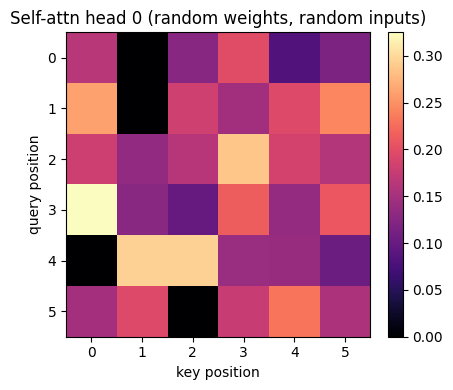

In [46]:
def scaled_dot_product_attention(
    q: torch.Tensor,
    k: torch.Tensor,
    v: torch.Tensor,
    attn_mask: Optional[torch.Tensor] = None,
    dropout_p: float = 0.0,
) -> Tuple[torch.Tensor, torch.Tensor]:
    # q,k,v: (B, n_heads, T, d_head)
    d_head = q.size(-1)
    scores = (q @ k.transpose(-2, -1)) / math.sqrt(d_head)  # (B, H, Tq, Tk)

    if attn_mask is not None:
        # attn_mask broadcastable to scores; True or 1 means "mask out"
        scores = scores.masked_fill(attn_mask, float("-inf"))

    attn = F.softmax(scores, dim=-1)
    if dropout_p > 0.0:
        attn = F.dropout(attn, p=dropout_p, training=True)
    out = attn @ v
    return out, attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout_p = dropout

    def forward(
        self,
        x: torch.Tensor,
        kv: Optional[torch.Tensor] = None,
        attn_mask: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        # x: (B, T, d). If kv is set, cross-attention (kv comes from encoder memory).
        if kv is None:
            kv = x
        B, Tq, _ = x.shape
        Tk = kv.size(1)

        q = self.w_q(x).view(B, Tq, self.n_heads, self.d_head).transpose(1, 2)
        k = self.w_k(kv).view(B, Tk, self.n_heads, self.d_head).transpose(1, 2)
        v = self.w_v(kv).view(B, Tk, self.n_heads, self.d_head).transpose(1, 2)

        out, attn = scaled_dot_product_attention(q, k, v, attn_mask=attn_mask, dropout_p=self.dropout_p if self.training else 0.0)
        out = out.transpose(1, 2).contiguous().view(B, Tq, self.d_model)
        return self.w_o(out), attn


# Smoke test
mha = MultiHeadAttention(64, 4).to(device)
x = torch.randn(2, 5, 64, device=device)
y, a = mha(x)
print(y.shape, a.shape)  # (2,5,64), (2,4,5,5)

# Random-init self-attention heatmap (one head) on a short random sequence
with torch.no_grad():
    _, a0 = mha(torch.randn(1, 6, 64, device=device))
plot_attention(a0[0, 0], title="Self-attn head 0 (random weights, random inputs)")


### Pause — what the attention code cell just did

**Step A.** It defined `scaled_dot_product_attention`: build scores, optionally apply a mask, softmax, then mix `V`.

**Step B.** It wrapped that in `MultiHeadAttention`: split hidden size into several **heads** so the model can attend in multiple “styles” in parallel.

**Step C.** It ran a **smoke test** on random numbers so you can see tensor shapes.

**Step D.** It plotted one head’s weights on random data — expect a **noisy** heatmap. That is normal before training; later you will see structured patterns in the decoder-only section.

When you are ready, the next section explains **why** we need positional information at all.

## 2. The position problem (why order matters)

Attention is **mostly blind to order** if you only pass it token embeddings.

### Step 1 — imagine two words

Suppose token A means “cat” and token B means “dog”. You can feed the model `[A, B]` or `[B, A]`. The **self-attention operation** (without extra position information) treats the set of pairs the same way up to reordering of outputs.

### Step 2 — what we want

Human sentences are **ordered**. “Cat bites dog” is not the same as “dog bites cat”.

### Step 3 — what we will add later

We will add **positional encoding** so that position 0 and position 1 are not interchangeable.

The code cell below runs a tiny sanity check: swap two rows in the input and notice how outputs swap in the same way. That is a feature of attention, not a bug—but it shows **why** we need position information for language.


In [47]:
def demo_permutation_without_pe():
    d_model = 32
    n_heads = 4
    mha = MultiHeadAttention(d_model, n_heads).eval()

    # Two tokens with different embeddings
    emb = nn.Parameter(torch.randn(2, d_model))  # positions 0 and 1
    seq_a = emb.unsqueeze(0)  # order [0,1]
    seq_b = torch.stack([emb[1], emb[0]], dim=0).unsqueeze(0)  # order [1,0]

    with torch.no_grad():
        out_a, _ = mha(seq_a)
        out_b, _ = mha(seq_b)
    # Output rows should swap when input rows swap (permutation equivariance)
    print("out_a[0,0] close to out_b[0,1]?", torch.allclose(out_a[0, 0], out_b[0, 1], atol=1e-5))
    print("out_a[0,1] close to out_b[0,0]?", torch.allclose(out_a[0, 1], out_b[0, 0], atol=1e-5))

demo_permutation_without_pe()


out_a[0,0] close to out_b[0,1]? True
out_a[0,1] close to out_b[0,0]? True


## 3. A “dummy” positional encoding (learned positions)

The simplest fix: **add a vector that depends only on the index** 0, 1, 2, … in the sentence.

### Step 1 — token embedding

Each **word type** gets a learned vector from an embedding table (for example the word “cat”).

### Step 2 — position embedding

Each **slot index** also gets a learned vector from a second table.

### Step 3 — add them

We **add** the two vectors. Now the same word type at two different positions has two different inputs to the rest of the network.

$$
x_i \leftarrow \mathrm{TokenEmbed}(w_i) + \mathrm{PosEmbed}(i)
$$

### Limits of this approach

- It only works up to **`max_len`** positions (we pick a cap).
- It does not tell the model anything in advance about **distance**; it must learn distance from data.

The next code cell defines this **learned** encoding and also the **sin/cos** encoding, then plots a few sine curves so you can *see* what “smooth position signal” means.


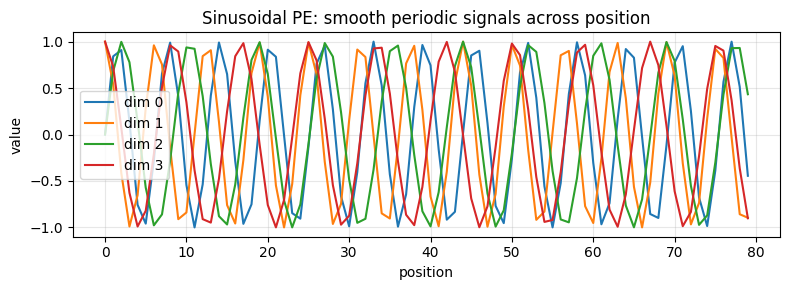

In [48]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 128):
        super().__init__()
        self.pos = nn.Embedding(max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d)
        T = x.size(1)
        idx = torch.arange(T, device=x.device).unsqueeze(0).expand(x.size(0), -1)
        return x + self.pos(idx)


class SinusoidalPositionalEncoding(nn.Module):
    # Fixed Vaswani et al. PE; optionally scaled and frozen.

    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        T = x.size(1)
        return x + self.pe[:, :T, :]


# Visual: first few dimensions of sinusoidal PE vs position
pe_layer = SinusoidalPositionalEncoding(64, max_len=128)
pe = pe_layer.pe[0].cpu().numpy()
plt.figure(figsize=(8, 3))
for dim in range(4):
    plt.plot(pe[:80, dim], label=f"dim {dim}")
plt.xlabel("position")
plt.ylabel("value")
plt.title("Sinusoidal PE: smooth periodic signals across position")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Pause — positional encodings you just ran

**Learned positions:** each index 0…`max_len-1` gets its own vector. Simple and effective, but it does not naturally describe “how far apart” two positions are.

**Sinusoidal positions:** fixed waves with different frequencies. The plot shows a few dimensions across positions — notice some curves change slowly and others wiggle faster.

Next we give a short **intuition** for why sine and cosine are a classic choice, then we build the reusable transformer layer used everywhere below.

## 4. Why sine and cosine for positions?

This section is **optional intuition**. Modern systems sometimes use other schemes (RoPE, ALiBi, etc.). The original transformer used sines and cosines for a clear geometric reason.

### Step 1 — fixed pattern, not learned

The sine/cosine pattern is **deterministic**: no extra weights to learn for position. That can help when data is small.

### Step 2 — different frequencies

Each pair of dimensions acts like a clock hand with a different rotation speed (different frequency). Early dimensions change slowly across position; later ones change quickly.

### Step 3 — relative shifts

For a fixed offset between two positions, the sine/cosine values at position *p* and at *p + offset* are related by a **simple linear transform** in a 2D plane. That makes it easier for linear layers in the network to represent **relative distance** patterns.

### Step 4 — what you will plot

The code draws a **2D curve** for one frequency: as position increases, the point moves on a circle. That is the geometric picture behind “sin/cos pairs.”


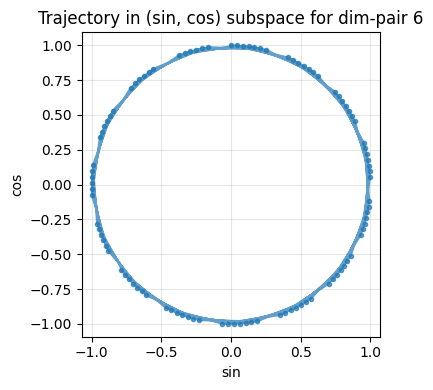

In [49]:
d_model = 64
i = 6  # pair index into sin/cos dimensions
div_term = math.exp(i * (-math.log(10000.0) / d_model))
positions = np.arange(0, 100)
angles = positions * div_term
plt.figure(figsize=(4, 4))
plt.plot(np.sin(angles), np.cos(angles), ".-", alpha=0.7)
plt.xlabel("sin")
plt.ylabel("cos")
plt.title(f"Trajectory in (sin, cos) subspace for dim-pair {i}")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Shared building blocks (one transformer layer)

Real transformers repeat a **block** many times. Here we keep one small block so the file stays readable.

### Inside one encoder-style block

1. **Layer normalization** — rescale and recenter activations (helps training stay stable).
2. **Self-attention** — mix information across positions (with the right mask for the task).
3. **Residual (“skip”) connection** — add the input of the sub-layer back to its output so gradients can flow easily.
4. **Feed-forward network** — a small two-layer MLP applied **separately at each position**. This adds non-linearity and capacity beyond pure attention.
5. **Another norm + residual** around the MLP.

We use **pre-norm** (normalize before attention and before the MLP), which is common in newer codebases.

### Decoder block (used later in encoder–decoder)

Same idea, but there are **two** attention steps:

1. **Masked self-attention** on the target language (Spanish) — causal: no future tokens.
2. **Cross-attention** — queries come from the decoder, but **keys and values** come from the **encoder memory** of the source sentence (English).

The next code cell defines these pieces and two helper masks: **causal** (for decoding) and **padding** (ignore batch padding).


In [50]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, attn_mask: Optional[torch.Tensor] = None):
        h = self.norm1(x)
        sa, attn = self.self_attn(h, attn_mask=attn_mask)
        x = x + sa
        x = x + self.ff(self.norm2(x))
        return x, attn


class DecoderLayer(nn.Module):
    # Self-attn (causal) + cross-attn to encoder memory + FFN.

    def __init__(self, d_model: int, n_heads: int, d_ff: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.norm3 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)

    def forward(self, x, memory, self_mask: Optional[torch.Tensor], memory_mask: Optional[torch.Tensor] = None):
        h = self.norm1(x)
        sa, attn_self = self.self_attn(h, attn_mask=self_mask)
        x = x + sa
        h2 = self.norm2(x)
        ca, attn_cross = self.cross_attn(h2, kv=memory, attn_mask=memory_mask)
        x = x + ca
        x = x + self.ff(self.norm3(x))
        return x, attn_self, attn_cross


def causal_mask(T: int, device) -> torch.Tensor:
    # Boolean mask (B=1,1,T,T) for scaled_dot_product: True = block.
    m = torch.triu(torch.ones(T, T, device=device, dtype=torch.bool), diagonal=1)
    return m.view(1, 1, T, T)


def padding_mask_from_lengths(lengths: torch.Tensor, T: int) -> torch.Tensor:
    # lengths: (B,) int — True where position >= length (pad). Shape (B,1,1,T) for broadcasting.
    B = lengths.size(0)
    idx = torch.arange(T, device=lengths.device).unsqueeze(0).expand(B, -1)
    return (idx >= lengths.unsqueeze(1)).view(B, 1, 1, T)


### Pause — you now have a full transformer “layer recipe”

You can think of the code cell above as a **repeatable recipe**:

1. normalize → 2. attention → 3. add residual → 4. normalize → 5. MLP → 6. add residual.

The encoder–decoder section **reuses** this recipe:

- the **encoder** uses self-attention on English,
- the **decoder** uses self-attention on Spanish **plus** a second attention that looks at English.

Next is the translation dataset and training loop.

## 6. Encoder–decoder on a tiny translation task

Here we train **English → Spanish** on a **very small** list of sentence pairs.

### Step 1 — what the data looks like

- **`EN_CORPUS`** — English lines.
- **`ES_TRANSLATIONS`** — Spanish lines in the **same order** (line *i* is the translation of line *i*).

We **reused** many short phrases on purpose (*i miss …*, *my dog …*) so the model can practice **patterns**, not only memorizing one long string.

### Step 2 — what the encoder does

The encoder reads the **English** tokens and produces a sequence of hidden vectors (“memory”). Every English position can attend to every other English position (subject to padding rules).

### Step 3 — what the decoder does

The decoder writes **Spanish** one token at a time during training (we use **teacher forcing**: we show it the correct previous Spanish tokens while it learns).

Inside the decoder:

- **Self-attention** is **causal** (it may not look at future Spanish).
- **Cross-attention** can look at **all** encoder positions for each Spanish step.

### Step 4 — loss

We compare the decoder’s predicted next-token distribution to the **true** next Spanish token, averaged over the batch. That is standard **cross-entropy** training.

### Step 5 — what to look for after training

The cell prints greedy translations for a couple of **seen** lines, then a **held-out** English line (*i miss my dog*) that was **not** in the training list. If training went well, the Spanish may still look reasonable because the model **recombined** patterns it saw in other lines.

**Important:** this is still a toy. A few hundred or thousand steps is tiny compared to real machine translation. Treat good results as a **teaching win**, not a guarantee.


Encoder–decoder (translation) loss: n=2500  loss_first=3.6879  loss_last=0.0006


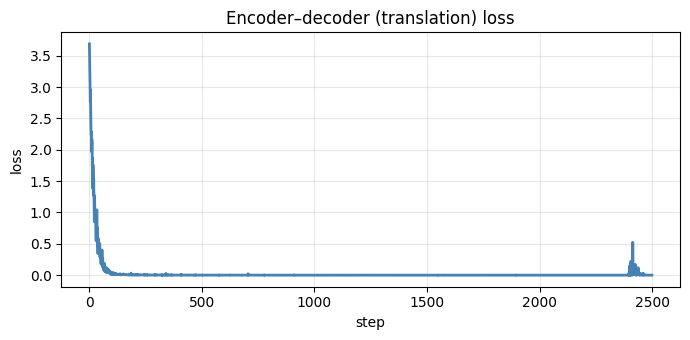

seen: extraño a mi gato
seen: mi perro está perdido
held-out: i miss my dog
model: extraño a mi perro
reference gloss (not in loss): extraño a mi perro
most overlapping training EN: i miss my cat
its Spanish: extraño a mi gato


In [51]:
@dataclass
class PhraseTokenizer:
    pad: str = "<pad>"
    sos: str = "<sos>"
    eos: str = "<eos>"

    def __init__(self, sentences, extra_tokens=()):
        tokens = set()
        for s in sentences:
            tokens.update(s.split())
        for s in (self.pad, self.sos, self.eos) + tuple(extra_tokens):
            tokens.add(s)
        self.itos = sorted(tokens)
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def encode(self, sent: str, add_sos_eos: bool = True):
        toks = sent.split()
        if add_sos_eos:
            toks = [self.sos] + toks + [self.eos]
        return [self.stoi[w] for w in toks]

    @property
    def vocab_size(self):
        return len(self.itos)


# One shared toy dataset:
# - EN_CORPUS: English lines used by encoder-only (MLM) and decoder-only (LM).
# - ES_TRANSLATIONS: aligned toy Spanish for encoder–decoder only.
EN_CORPUS = [
    # --- compositional "miss / my / dog / cat" family (overlap on purpose) ---
    "i miss my cat",
    "i miss you",
    "my dog is missing",
    "i miss my home",
    "my cat is missing",
    "i love my dog",
    "i love my cat",
    "i miss the sun",
    "my dog runs",
    "i miss my mom",
    "my dog is happy",
    "i see my dog",
    # --- a few more lines so LM / MLM still see other words ---
    "the sun is bright",
    "we go home",
    "she reads books",
]

ES_TRANSLATIONS = [
    "extraño a mi gato",
    "te extraño",
    "mi perro está perdido",
    "extraño mi hogar",
    "mi gato está perdido",
    "amo a mi perro",
    "amo a mi gato",
    "extraño el sol",
    "mi perro corre",
    "extraño a mi mamá",
    "mi perro está feliz",
    "veo a mi perro",
    "el sol es brillante",
    "vamos a casa",
    "ella lee libros",
]

PAIRS = list(zip(EN_CORPUS, ES_TRANSLATIONS))

src_lines = [p[0] for p in PAIRS]
tgt_lines = [p[1] for p in PAIRS]
tok_src = PhraseTokenizer(src_lines)
tok_tgt = PhraseTokenizer(tgt_lines)


def pad_batch(seqs, pad_id, device):
    T = max(len(s) for s in seqs)
    out = torch.full((len(seqs), T), pad_id, dtype=torch.long, device=device)
    lengths = []
    for i, s in enumerate(seqs):
        out[i, : len(s)] = torch.tensor(s, device=device)
        lengths.append(len(s))
    return out, torch.tensor(lengths, device=device, dtype=torch.long)


class EncoderDecoderTransformer(nn.Module):
    def __init__(
        self,
        src_vocab: int,
        tgt_vocab: int,
        d_model: int = 128,
        n_heads: int = 4,
        d_ff: int = 256,
        n_enc: int = 2,
        n_dec: int = 2,
        max_len: int = 64,
        dropout: float = 0.1,
        pos: str = "sin",  # "sin" or "learned"
    ):
        super().__init__()
        self.src_emb = nn.Embedding(src_vocab, d_model)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model)
        if pos == "sin":
            self.pe_src = SinusoidalPositionalEncoding(d_model, max_len)
            self.pe_tgt = SinusoidalPositionalEncoding(d_model, max_len)
        else:
            self.pe_src = LearnedPositionalEncoding(d_model, max_len)
            self.pe_tgt = LearnedPositionalEncoding(d_model, max_len)
        self.enc_layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_enc)])
        self.dec_layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_dec)])
        self.lm_head = nn.Linear(d_model, tgt_vocab)

    def encode(self, src_ids, src_lengths):
        x = self.pe_src(self.src_emb(src_ids))
        T = x.size(1)
        pad_m = padding_mask_from_lengths(src_lengths, T)
        # Mask only PAD *keys* (not pad queries). Masking pad *queries* would block all keys
        # for padded rows → softmax(-inf) = NaN and the loss plot breaks.
        attn_pad = pad_m
        for layer in self.enc_layers:
            x, _ = layer(x, attn_mask=attn_pad)
        return x, pad_m

    def decode(self, tgt_ids, memory, src_pad_mask, return_attention: bool = False):
        x = self.pe_tgt(self.tgt_emb(tgt_ids))
        Tt, Ts = x.size(1), memory.size(1)
        self_m = causal_mask(Tt, x.device)
        # decoder keys: also mask pad positions in decoder inputs (not critical here)
        mem_mask = src_pad_mask.expand(-1, -1, Tt, Ts)  # (B,1,Tt,Ts) mask encoder keys per query
        attns_cross = []
        attns_self = []
        for layer in self.dec_layers:
            x, a_self, a_cross = layer(x, memory, self_mask=self_m, memory_mask=mem_mask)
            if return_attention:
                attns_self.append(a_self)
                attns_cross.append(a_cross)
        logits = self.lm_head(x)
        if return_attention:
            return logits, attns_self, attns_cross
        return logits

    def forward(self, src_ids, src_lengths, tgt_in_ids):
        mem, src_pad = self.encode(src_ids, src_lengths)
        return self.decode(tgt_in_ids, mem, src_pad)


def train_encdec(steps: int = 400, lr: float = 3e-4):
    model = EncoderDecoderTransformer(tok_src.vocab_size, tok_tgt.vocab_size).to(device)
    model.train()
    opt = AdamW(model.parameters(), lr=lr)
    pad_s, pad_t = tok_src.stoi[tok_src.pad], tok_tgt.stoi[tok_tgt.pad]
    sos_t, eos_t = tok_tgt.stoi[tok_tgt.sos], tok_tgt.stoi[tok_tgt.eos]
    losses = []

    for step in range(steps):
        idx = torch.randint(0, len(PAIRS), (8,))
        src_raw = [tok_src.encode(src_lines[i]) for i in idx]
        tgt_raw = [tok_tgt.encode(tgt_lines[i]) for i in idx]
        src_b, src_len = pad_batch(src_raw, pad_s, device)
        tgt_full, _ = pad_batch(tgt_raw, pad_t, device)
        tgt_in = tgt_full[:, :-1]
        tgt_out = tgt_full[:, 1:]
        logits = model(src_b, src_len, tgt_in)
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1), ignore_index=pad_t)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    plot_loss_curve(losses, "Encoder–decoder (translation) loss")
    return model

encdec_model = train_encdec(2500)


@torch.no_grad()
def greedy_translate(model: EncoderDecoderTransformer, src_sent: str):
    model.eval()
    pad_s = tok_src.stoi[tok_src.pad]
    sos_t, eos_t = tok_tgt.stoi[tok_tgt.sos], tok_tgt.stoi[tok_tgt.eos]
    src_ids = torch.tensor([tok_src.encode(src_sent)], device=device)
    src_len = torch.tensor([src_ids.size(1)], device=device)
    mem, src_pad = model.encode(src_ids, src_len)
    ys = torch.tensor([[sos_t]], device=device)
    for _ in range(28):
        logits = model.decode(ys, mem, src_pad)
        next_id = logits[0, -1].argmax()
        ys = torch.cat([ys, next_id.view(1, 1)], dim=1)
        if next_id.item() == eos_t:
            break
    out = [tok_tgt.itos[i] for i in ys[0].tolist() if i not in (sos_t, eos_t, tok_tgt.stoi[tok_tgt.pad])]
    return " ".join(out)

print("seen:", greedy_translate(encdec_model, "i miss my cat"))
print("seen:", greedy_translate(encdec_model, "my dog is missing"))

# Held-out combination: every token appears in training, but this exact source line does not.
held_out = "i miss my dog"
assert held_out not in src_lines
print("held-out:", held_out)
print("model:", greedy_translate(encdec_model, held_out))
print("reference gloss (not in loss): extraño a mi perro")

best_i = max(
    range(len(src_lines)),
    key=lambda i: len(set(held_out.split()) & set(src_lines[i].split())),
)
print("most overlapping training EN:", src_lines[best_i])
print("its Spanish:", tgt_lines[best_i])


### Reading attention for *i miss my dog*

This section is optional but useful if you like **pictures** more than formulas.

### Two kinds of attention in the decoder

1. **Decoder self-attention (causal)**  
   Each Spanish position builds a view of the **Spanish so far** (prefix only). This helps grammar and local word choice inside Spanish.

2. **Encoder–decoder (“cross”) attention**  
   Each Spanish position also assigns weights to **English encoder positions**. Think: “while I am writing this Spanish word, which English words should I lean on?”

### What the plots are *not*

They are **not** a certified word alignment from linguistics. They are **soft weights** from one layer (after averaging heads for readability).

### How we build the plots (teacher forcing)

To get a **single** clean matrix, we do **not** run greedy decoding step by step here. Instead we:

1. Fix the English source (for example the held-out sentence).
2. Fix the Spanish target string to the **reference gloss** we printed earlier (the same string greedy decoding found when training succeeded).
3. Feed Spanish **up to but not including** the final `<eos>` exactly like in training (`tgt_in`).
4. Run the decoder **one forward pass** in parallel and read off the **last layer** attention.

That answers: “If the model is aiming at this Spanish sentence, **where does it look** on the English side at each depth?”

### How to read the cross-attention heatmap

- **Rows** — decoder time steps (roughly: positions along the Spanish prefix we fed in).
- **Columns** — encoder time steps (English tokens, including special tokens).
- **Darker** — higher weight.

### The extra charts

- **Row entropy** — if one row uses weight on many English columns, entropy is **high** (spread out). If mass concentrates on one or two English words, entropy is **low** (focused).
- **Argmax table** — for each decoder row, which **single** English column wins? This is a crude “hard alignment” snapshot.

We show the **held-out** pair and a **seen** pair side by side so you can compare shapes.


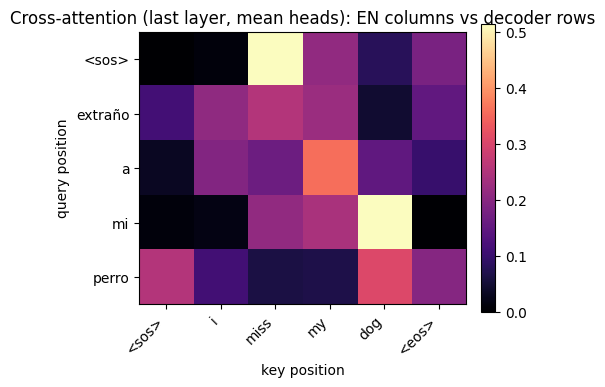

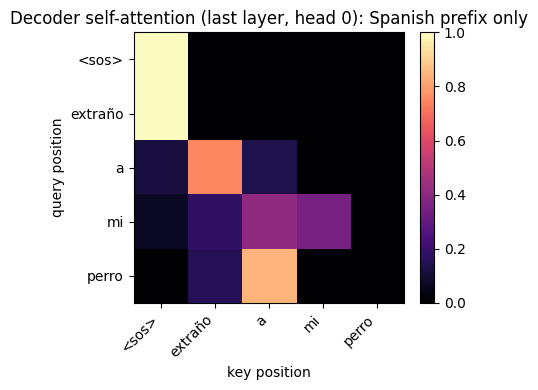

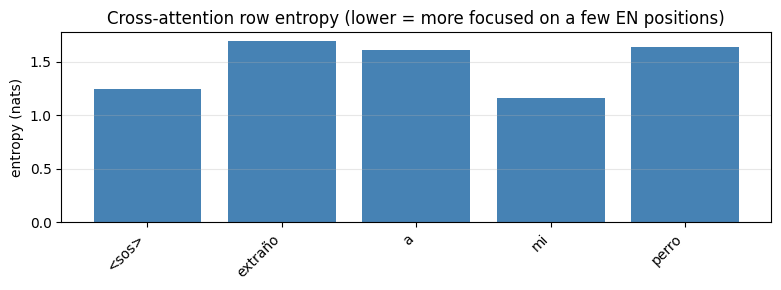

Discrete argmax over EN positions (per decoder row, mean heads):
  dec  0 <sos>           ->  strongest EN column: miss            (enc idx 2)
  dec  1 extraño         ->  strongest EN column: miss            (enc idx 2)
  dec  2 a               ->  strongest EN column: my              (enc idx 3)
  dec  3 mi              ->  strongest EN column: dog             (enc idx 4)
  dec  4 perro           ->  strongest EN column: dog             (enc idx 4)


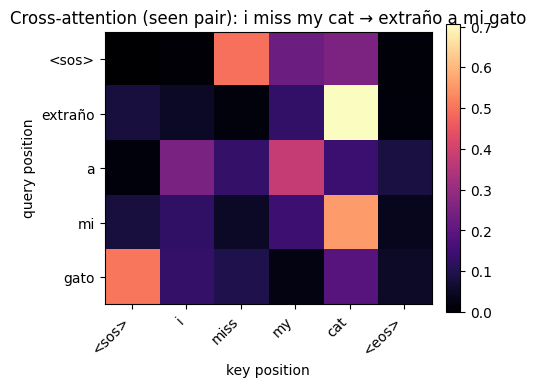

Argmax alignment (seen pair):
  dec  0 <sos>           ->  strongest EN column: miss            (enc idx 2)
  dec  1 extraño         ->  strongest EN column: cat             (enc idx 4)
  dec  2 a               ->  strongest EN column: my              (enc idx 3)
  dec  3 mi              ->  strongest EN column: cat             (enc idx 4)
  dec  4 gato            ->  strongest EN column: <sos>           (enc idx 0)


In [52]:
@torch.no_grad()
def encdec_teacher_forcing_attns(
    model: EncoderDecoderTransformer, src_sent: str, tgt_sent_es: str
):
    """Run decoder with teacher-forced Spanish prefix (same layout as training)."""
    model.eval()
    src_ids = torch.tensor([tok_src.encode(src_sent)], device=device)
    src_len = torch.tensor([src_ids.size(1)], device=device)
    mem, src_pad = model.encode(src_ids, src_len)
    tgt_seq = tok_tgt.encode(tgt_sent_es)
    tgt_in = torch.tensor([tgt_seq[:-1]], device=device)
    _, attns_self, attns_cross = model.decode(tgt_in, mem, src_pad, return_attention=True)
    return attns_self, attns_cross, src_ids[0], tgt_in[0]


def _lbl_tok(ids_1d, tok):
    return [tok.itos[int(i)] for i in ids_1d.tolist()]


def plot_cross_mean_heads(attns_cross, src_ids_1d, tgt_in_1d, title):
    """Last layer, mean over heads -> (T_dec, T_enc)."""
    A = attns_cross[-1][0].mean(dim=0).float().cpu().numpy()
    row_lbl = _lbl_tok(tgt_in_1d, tok_tgt)
    col_lbl = _lbl_tok(src_ids_1d, tok_src)
    plot_attention(torch.tensor(A), row_labels=row_lbl, col_labels=col_lbl, title=title)


def plot_self_last_head0(attns_self, tgt_in_1d, title):
    A = attns_self[-1][0, 0].float().cpu().numpy()
    lab = _lbl_tok(tgt_in_1d, tok_tgt)
    plot_attention(torch.tensor(A), row_labels=lab, col_labels=lab, title=title)


def plot_row_entropy_cross(attns_cross, tgt_in_1d, title):
    A = attns_cross[-1][0].mean(dim=0)  # (T_dec, T_enc)
    ent = -(A * (A + 1e-12).log()).sum(dim=-1).float().cpu().numpy()
    labs = _lbl_tok(tgt_in_1d, tok_tgt)
    plt.figure(figsize=(8, 3))
    plt.bar(range(len(ent)), ent, color="steelblue")
    plt.xticks(range(len(labs)), labs, rotation=45, ha="right")
    plt.ylabel("entropy (nats)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def print_argmax_src_for_rows(attns_cross, src_ids_1d, tgt_in_1d, heading):
    A = attns_cross[-1][0].mean(dim=0)  # (T_dec, T_enc)
    mx = A.argmax(dim=-1).cpu().numpy()
    src_lbl = _lbl_tok(src_ids_1d, tok_src)
    tgt_lbl = _lbl_tok(tgt_in_1d, tok_tgt)
    print(heading)
    for i, tw in enumerate(tgt_lbl):
        j = int(mx[i])
        print(f"  dec {i:2d} {tw:14s}  ->  strongest EN column: {src_lbl[j]:14s}  (enc idx {j})")


# --- Held-out EN + reference ES (matches greedy output when training succeeded) ---
src_hold = "i miss my dog"
tgt_hold = "extraño a mi perro"
self_h, cross_h, src_ids_h, tgt_in_h = encdec_teacher_forcing_attns(encdec_model, src_hold, tgt_hold)

plot_cross_mean_heads(
    cross_h,
    src_ids_h,
    tgt_in_h,
    "Cross-attention (last layer, mean heads): EN columns vs decoder rows",
)
plot_self_last_head0(
    self_h,
    tgt_in_h,
    "Decoder self-attention (last layer, head 0): Spanish prefix only",
)
plot_row_entropy_cross(
    cross_h,
    tgt_in_h,
    "Cross-attention row entropy (lower = more focused on a few EN positions)",
)
print_argmax_src_for_rows(
    cross_h,
    src_ids_h,
    tgt_in_h,
    "Discrete argmax over EN positions (per decoder row, mean heads):",
)

# --- Seen training pair for contrast ---
src_seen = "i miss my cat"
tgt_seen = "extraño a mi gato"
self_s, cross_s, src_ids_s, tgt_in_s = encdec_teacher_forcing_attns(encdec_model, src_seen, tgt_seen)

plot_cross_mean_heads(
    cross_s,
    src_ids_s,
    tgt_in_s,
    "Cross-attention (seen pair): i miss my cat → extraño a mi gato",
)
print_argmax_src_for_rows(
    cross_s,
    src_ids_s,
    tgt_in_s,
    "Argmax alignment (seen pair):",
)


### Generalizing versus memorizing (keep expectations clear)

### What we *designed* the toy data to do

Many training sentences **share pieces** of language: the same short English starts, the same kinds of Spanish endings, repeated *mi perro* patterns, and so on.

That overlap is what makes it **possible** (not automatic) for a neural net to **recombine** pieces when it sees a new English sentence like *i miss my dog*.

### What the training loss actually asks

The model is never told explicitly: “swap *gato* for *perro* here.” The loss only says: **make the whole Spanish output likely** when conditioned on the whole English input.**

So good behavior on a held-out line is **emergent**. It comes from enough capacity, enough steps, and helpful patterns in the data.

### If the held-out line is wrong

That can still be normal at this scale. Levers that usually help (same architecture, more budget):

- more training steps,
- a slightly wider model,
- **beam search** instead of greedy decoding,
- more diverse parallel sentences.

The point of the notebook is to show the **mechanisms** (attention, masks, layouts). The toy numbers are only large enough to make some demos work on a laptop.


## 7. Encoder-only (bidirectional attention + padding mask)

This layout is closer in spirit to **BERT-style** models than to GPT: every token may attend **left and right** inside the sentence.

### Step 1 — why bidirectional is useful

If you want to fill in a blank in the middle of a sentence, you need both **left** and **right** context. A causal decoder cannot see the right side yet, so it is the wrong tool for that specific “fill in the blank” training game.

### Step 2 — padding in batches

When sentences in a batch have different lengths, we pad shorter ones with a **`<pad>`** token. We must **mask** padding so attention does not treat empty slots as real words.

### Step 3 — the toy task here (simple MLM)

We take a normal English line from the shared corpus, replace **one** word with `<mask>`, and ask the model to **predict that word** from context.

### Step 4 — what you should see

Loss should go **down** over steps. The model is learning contextual clues, not a full chat bot.

This section reuses **`EN_CORPUS`** from earlier so vocabulary stays aligned with the rest of the notebook.


Encoder-only (single-token MLM) loss: n=600  loss_first=3.3432  loss_last=0.3109


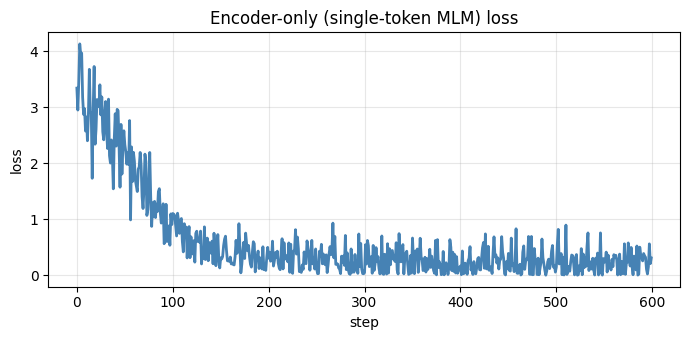

In [53]:
class EncoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model=128, n_heads=4, d_ff=256, n_layers=2, max_len=64, dropout=0.1):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d_model)
        self.pe = SinusoidalPositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, ids, lengths, attn_mask_extra: Optional[torch.Tensor] = None):
        x = self.pe(self.tok(ids))
        T = x.size(1)
        pad_m = padding_mask_from_lengths(lengths, T)
        attn_pad = pad_m  # mask pad keys only (see encoder–decoder cell)
        if attn_mask_extra is not None:
            attn_pad = attn_pad | attn_mask_extra
        last_attn = None
        for layer in self.layers:
            x, last_attn = layer(x, attn_mask=attn_pad)
        return self.head(x), last_attn


def train_encoder_only(steps: int = 500):
    all_sents = [p[0] for p in PAIRS] + [p[1] for p in PAIRS]
    tok = PhraseTokenizer(all_sents, extra_tokens=("<mask>",))
    vocab_size = tok.vocab_size
    pad_id = tok.stoi[tok.pad]

    model = EncoderOnlyTransformer(vocab_size).to(device)
    model.train()
    opt = AdamW(model.parameters(), lr=3e-4)
    lines = list(EN_CORPUS) * 4  # repeat for more batches
    losses = []

    for step in range(steps):
        batch_lines = random.sample(lines, k=min(8, len(lines)))
        ids_list = []
        labels_list = []
        lens = []
        for s in batch_lines:
            toks = [tok.stoi[w] for w in s.split()]
            if len(toks) < 2:
                continue
            j = random.randrange(len(toks))
            masked = toks.copy()
            true_tok = masked[j]
            masked[j] = tok.stoi["<mask>"]
            ids_list.append(masked)
            lab = [-100] * len(masked)
            lab[j] = true_tok
            labels_list.append(lab)
            lens.append(len(masked))
        if not ids_list:
            continue
        Tm = max(lens)
        ids = torch.full((len(ids_list), Tm), pad_id, dtype=torch.long, device=device)
        labels = torch.full((len(ids_list), Tm), -100, dtype=torch.long, device=device)
        length_t = torch.tensor(lens, device=device)
        for i, row in enumerate(ids_list):
            ids[i, : len(row)] = torch.tensor(row, device=device)
            for t, lab in enumerate(labels_list[i]):
                if lab != -100:
                    labels[i, t] = lab
        logits, _ = model(ids, length_t)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), labels.reshape(-1), ignore_index=-100)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    plot_loss_curve(losses, "Encoder-only (single-token MLM) loss")
    return model, tok

enc_only_model, enc_tok = train_encoder_only(600)


## 8. Decoder-only language model (causal / “GPT-style”)

Here the model is trained to predict **the next token** given all **previous** tokens.

### Step 1 — the causal rule

At position *t*, the model may build features using tokens **0 … t** only. It must **not** use token *t+1* or anything after it. Otherwise training would **cheat** by peeking at the answer.

We enforce that with a **causal mask** on attention scores (upper triangle set to “forbidden”).

### Step 2 — training loss

We feed whole padded sentences. For each position, we ask: “given everything to the left, what is the **next** token?” That is standard **language modeling** loss (cross-entropy on the next token).

### Step 3 — padding plus causal

Padding tokens are also masked out where appropriate so softmax never has to attend to “empty” keys.

### Step 4 — generation (greedy)

After training, we can **continue** a short prompt. Important detail:

- During training, each training string ends with an **`<eos>`** token.
- When **generating**, we start from **`<sos>` + your prompt words** and we **do not** place an `<eos>` in the starting context. If we did, the first “next token” prediction would happen **after** end-of-sentence and the run would often stop immediately (you would only see your prompt echoed back).

The code cell plots the causal mask so the allowed region is visually obvious, then trains, then prints a few greedy continuations.

### What to expect from generations

The corpus is small. Outputs may be **short**, **repetitive**, or **odd**. That is normal here. Watch whether continuations **sound like** the training phrases—that is the sanity check at toy scale.


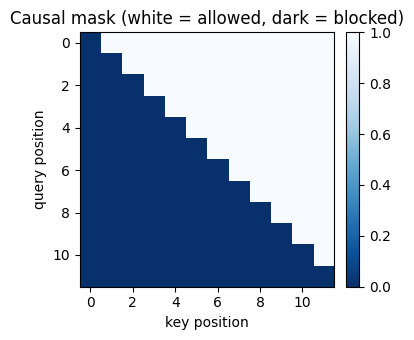

Decoder-only (causal LM) loss: n=1000  loss_first=3.4099  loss_last=0.5877


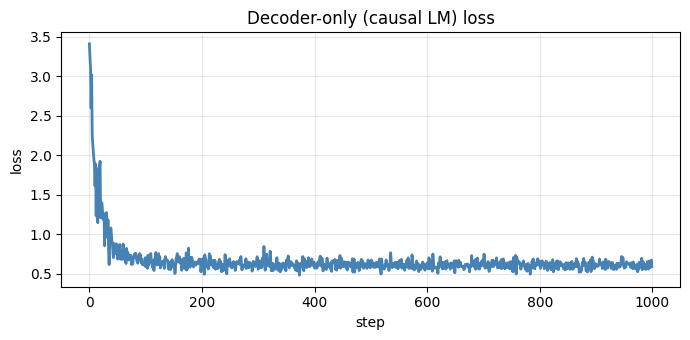

prompt: 'i miss' -> i miss my home
prompt: 'my dog' -> my dog is happy
prompt: 'i miss my' -> i miss my home


In [54]:
# Causal mask: queries (rows) cannot attend to future keys (columns)
M = causal_mask(12, device)[0, 0].float().cpu().numpy()
plt.figure(figsize=(4, 3.5))
plt.imshow(M, cmap="Blues_r", vmin=0, vmax=1)
plt.xlabel("key position")
plt.ylabel("query position")
plt.title("Causal mask (white = allowed, dark = blocked)")
plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


class DecoderOnlyTransformer(nn.Module):
    def __init__(self, vocab_size: int, d_model=128, n_heads=4, d_ff=256, n_layers=3, max_len=96, dropout=0.1):
        super().__init__()
        self.tok = nn.Embedding(vocab_size, d_model)
        self.pe = SinusoidalPositionalEncoding(d_model, max_len)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, ids, lengths, return_attention: bool = False):
        x = self.pe(self.tok(ids))
        T = x.size(1)
        pad_m = padding_mask_from_lengths(lengths, T)
        pad_attn = pad_m  # pad keys only; causal handles “no future”
        causal = causal_mask(T, ids.device)
        attn_mask = pad_attn | causal
        attns = []
        for layer in self.layers:
            x, a = layer(x, attn_mask=attn_mask)
            attns.append(a)
        logits = self.head(x)
        if return_attention:
            return logits, attns
        return logits


# Same EN_CORPUS as enc–dec / encoder-only (defined a few cells above).
lm_tok = PhraseTokenizer(EN_CORPUS)


def lm_batch(device, batch_size=8):
    pad_id = lm_tok.stoi[lm_tok.pad]
    rows = [lm_tok.encode(random.choice(EN_CORPUS), add_sos_eos=True) for _ in range(batch_size)]
    return pad_batch(rows, pad_id, device)


def train_decoder_only(steps: int = 800):
    model = DecoderOnlyTransformer(lm_tok.vocab_size, n_layers=3).to(device)
    model.train()
    opt = AdamW(model.parameters(), lr=3e-4)
    pad_id = lm_tok.stoi[lm_tok.pad]
    losses = []

    for step in range(steps):
        ids, lens = lm_batch(device, 8)
        logits = model(ids, lens)
        # next-token prediction: align logits[:,:-1] with ids[:,1:]
        loss = F.cross_entropy(
            logits[:, :-1, :].reshape(-1, lm_tok.vocab_size),
            ids[:, 1:].reshape(-1),
            ignore_index=pad_id,
        )
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())

    plot_loss_curve(losses, "Decoder-only (causal LM) loss")
    return model

dec_model = train_decoder_only(1000)


@torch.no_grad()
def generate_greedy(model: DecoderOnlyTransformer, prompt: str, max_new: int = 24):
    model.eval()
    # IMPORTANT: do not put <eos> in the initial context. encode(..., add_sos_eos=True)
    # ends with <eos>, so the first "next token" is predicted *after* sentence end — the
    # model often predicts <eos> again immediately and you only see the prompt repeated.
    body = [lm_tok.stoi[w] for w in prompt.split() if w in lm_tok.stoi]
    unk_words = [w for w in prompt.split() if w not in lm_tok.stoi]
    if unk_words:
        raise ValueError(f"unknown words in prompt (not in training vocab): {unk_words}")
    ctx = [lm_tok.stoi[lm_tok.sos]] + body
    out = torch.tensor([ctx], device=device, dtype=torch.long)
    eos_id = lm_tok.stoi[lm_tok.eos]
    for _ in range(max_new):
        lens = torch.tensor([out.size(1)], device=device, dtype=torch.long)
        logits = model(out, lens)
        nxt = int(logits[0, -1].argmax().item())
        if nxt == eos_id:
            break
        out = torch.cat([out, torch.tensor([[nxt]], device=device, dtype=torch.long)], dim=1)
    words = [
        lm_tok.itos[i]
        for i in out[0].tolist()
        if lm_tok.itos[i] not in (lm_tok.sos, lm_tok.eos, lm_tok.pad)
    ]
    return " ".join(words)

print("prompt:", repr("i miss"), "->", generate_greedy(dec_model, "i miss"))
print("prompt:", repr("my dog"), "->", generate_greedy(dec_model, "my dog"))
print("prompt:", repr("i miss my"), "->", generate_greedy(dec_model, "i miss my"))


## 9. Attention before versus after training (decoder-only)

We plot **self-attention** (Spanish/English **same** stream here—just one language) for a short prompt.

### Step 1 — random model

First we build a **fresh** decoder with random weights. The heatmap is usually **messy**: the model has not learned linguistics yet.

### Step 2 — trained model

Then we plot the **same head** (head 0 of the **last** layer) after the small LM training loop.

### Step 3 — how to interpret changes

You might see **sharper** peaks or **more structured** patterns after training. Do not over-interpret a single head: real models use many heads and many layers, and attention is not the only pathway of information (there are also skip connections and MLPs).

The goal is simply to connect **training** to a **visible** change in internal weights.


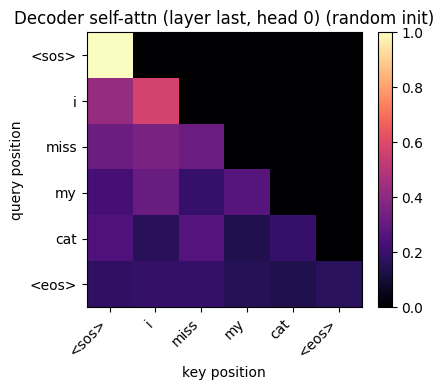

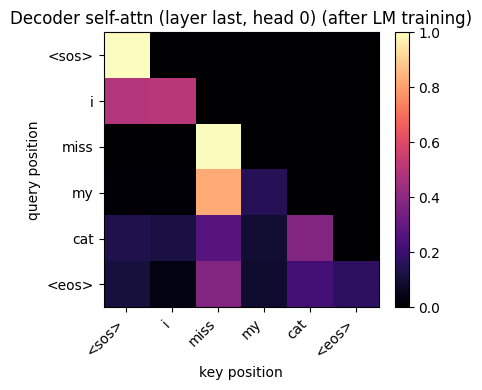

In [55]:
def show_decoder_attention(model: DecoderOnlyTransformer, prompt: str, title_suffix: str):
    model.eval()
    ids, lens = pad_batch([lm_tok.encode(prompt, add_sos_eos=True)], lm_tok.stoi[lm_tok.pad], device)
    _, attns = model(ids, lens, return_attention=True)
    # last layer head 0
    a = attns[-1][0, 0]  # (T,T)
    labs = lm_tok.encode(prompt, add_sos_eos=True)
    lab_words = [lm_tok.itos[i] for i in labs]
    plot_attention(a, row_labels=lab_words, col_labels=lab_words, title=f"Decoder self-attn (layer last, head 0) {title_suffix}")


fresh = DecoderOnlyTransformer(lm_tok.vocab_size, n_layers=2).to(device)
show_decoder_attention(fresh, "i miss my cat", "(random init)")
show_decoder_attention(dec_model, "i miss my cat", "(after LM training)")


## 10. Optional architecture diagram (PyGraphviz)

This section is **optional**. If the import fails, you can still finish the notebook; you will only miss one picture.

### What the diagram shows

A **high-level flowchart**:

- token ids → embeddings + position
- encoder stack
- decoder stack (receives encoder memory)
- final linear layer to logits

### If you want the image to render

1. Install the Graphviz **program** on your computer (not only the Python package).
2. Install **pygraphviz** in the same Python environment as `torch`.

Then re-run the cell; it writes a PNG next to the notebook and tries to display it inline.


In [56]:
def draw_transformer_arch(path="transformer_arch.png"):
    try:
        import pygraphviz as pgv
    except ImportError:
        print("pygraphviz not installed; skip graph.")
        return
    from pathlib import Path
    from IPython.display import Image, display

    G = pgv.AGraph(directed=True, rankdir="TB", bgcolor="white", fontname="Helvetica")
    G.node_attr["shape"] = "box"
    G.node_attr["style"] = "rounded,filled"
    G.node_attr["fillcolor"] = "#e8f0fe"

    def n(name, label):
        G.add_node(name, label=label)

    n("in", "Input token IDs")
    n("emb", "Token embedding + positional encoding")
    n("enc", "Encoder stack\n(self-attn + FFN)")
    n("dec", "Decoder stack\n(masked self-attn + cross-attn + FFN)")
    n("lm", "Linear head → logits")
    G.add_edge("in", "emb")
    G.add_edge("emb", "enc")
    G.add_edge("emb", "dec")
    G.add_edge("enc", "dec", label="memory")
    G.add_edge("dec", "lm")

    G.layout(prog="dot")
    outp = Path(path)
    G.draw(outp)
    print("Wrote", outp.resolve())
    display(Image(filename=str(outp)))


draw_transformer_arch("transformer_arch.png")


pygraphviz not installed; skip graph.
